In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,precision_score,recall_score,f1_score
from sklearn.model_selection import train_test_split

#### Task 1: Exploratory Data Analysis

In [3]:
df=pd.read_csv('wine.csv')

In [4]:
df.shape

(178, 14)

In [5]:
df.head(3)

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


### From the information given, the dataset has all numerical columns with 11 of float type and 3 of integer type

In [7]:
#### Statistical information
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [8]:
### Checking missing values
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [9]:
### Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
### Hence the given dataset has no missing values and no duplictaes

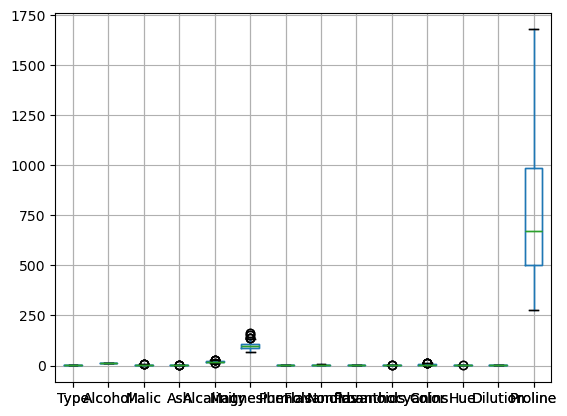

In [14]:
### Checking for outliers
df.boxplot()
plt.show()

In [15]:
### Removing the outliers using capping technique
def outlier_capping(df,column):

    Q1= df[column].quantile(0.25)

    Q3= df[column].quantile(0.75)

    IQR= Q3-Q1

    lower_extreme= Q1-1.5*IQR

    upper_extreme= Q3+1.5*IQR

    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)

for col in df.select_dtypes(['int','float']).columns:

    outlier_capping(df,col)

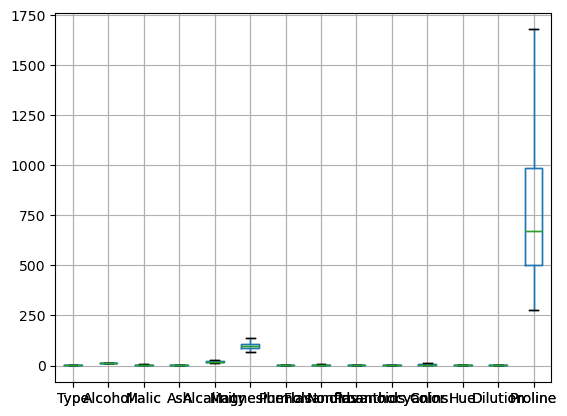

In [17]:
### Now again checking whether the outliers are removed or not
df.boxplot()
plt.show()

#### Examine the distribution of features using histograms, box plots, or density plots.

In [26]:
### findingnthe numerical column
num_col= df.select_dtypes (include=['float64','int64']).columns
num_col

Index(['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

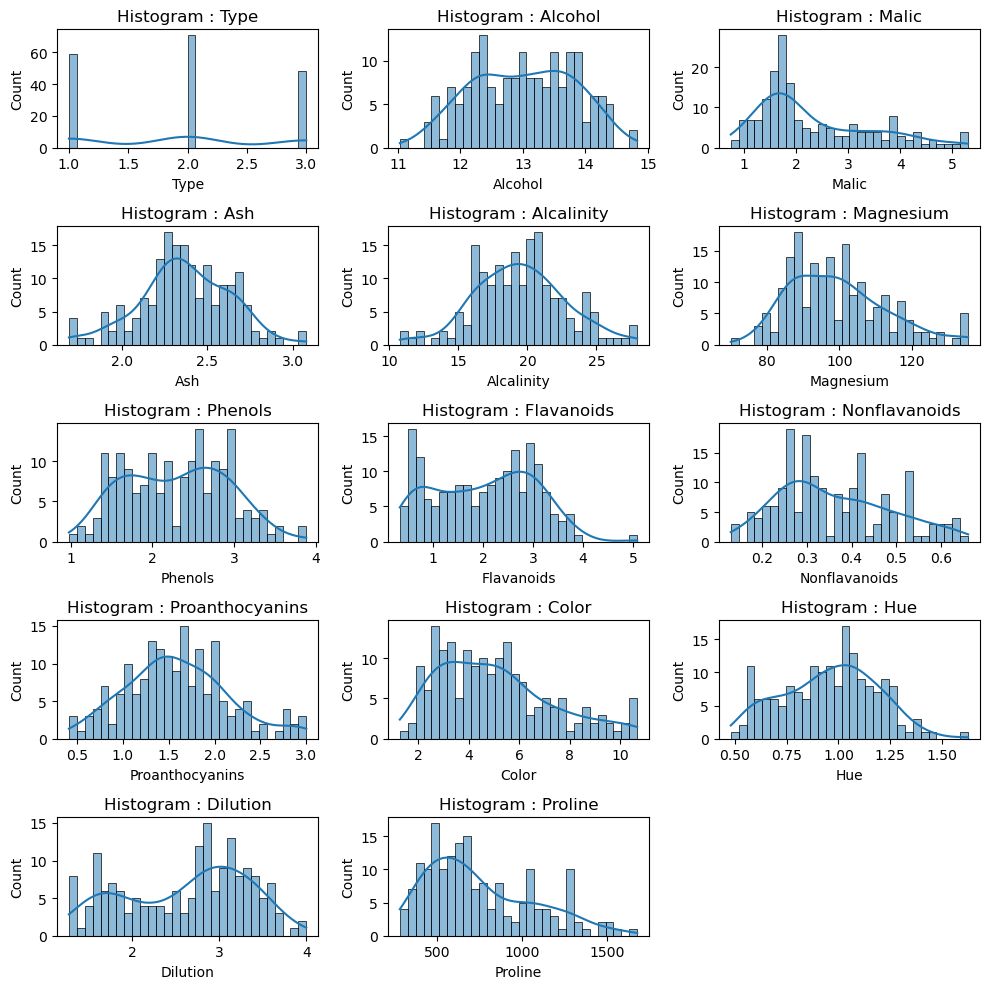

In [27]:
### Plottting Histplot to see the feature distribution
plt.figure(figsize = (10,10))
for i, col in enumerate(num_col, 1 ):
    plt.subplot(5,3,i)
    sns.histplot(df[col], kde = True, bins = 30)
    plt.title(f'Histogram : {col}')
plt.tight_layout()
plt.show()

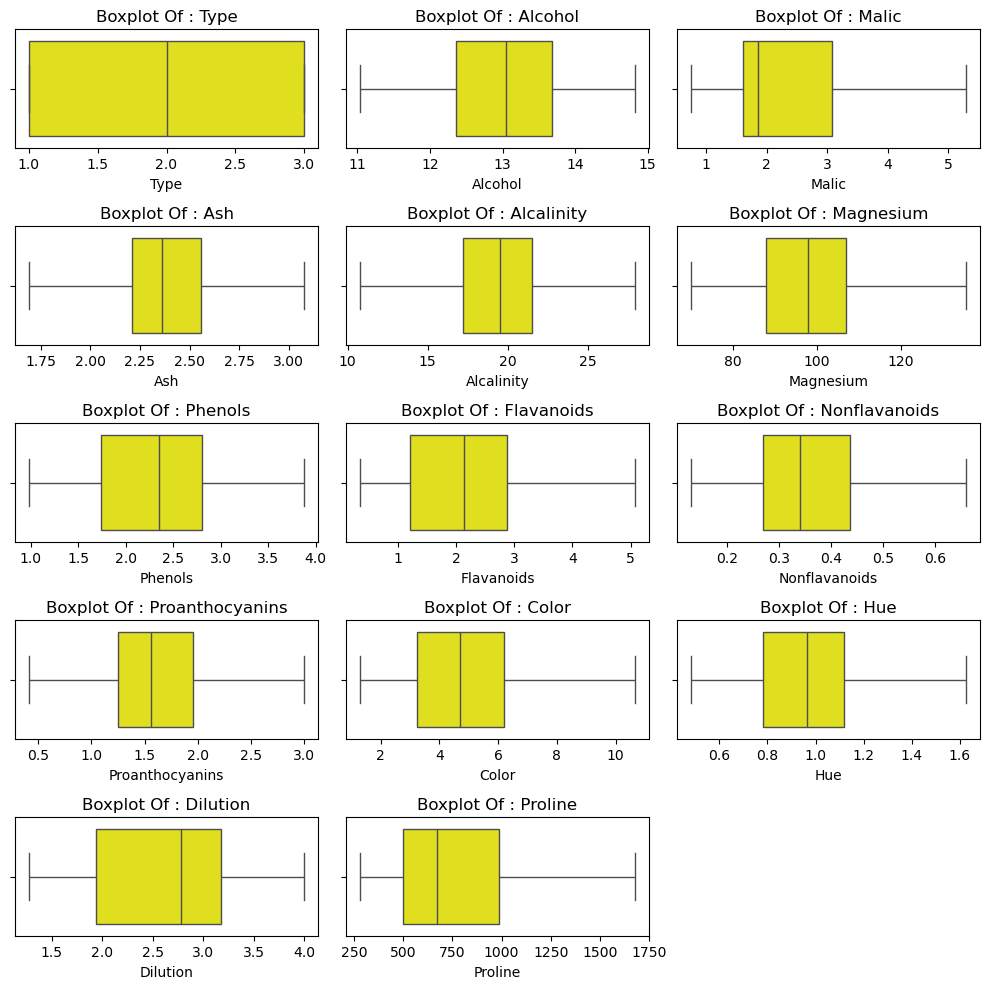

In [28]:
### Plotting boxplot 

plt.figure(figsize = (10,10))
for i, col in enumerate(num_col, 1 ):
    plt.subplot(5,3,i)
    sns.boxplot(x = df[col] , color = 'yellow')
    plt.title(f'Boxplot Of : {col}')
plt.tight_layout()
plt.show()

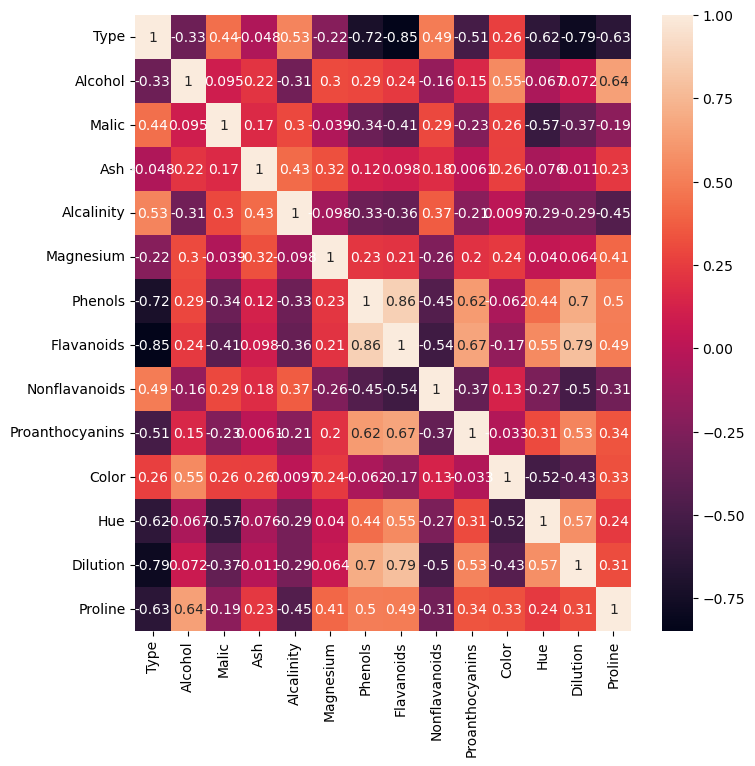

In [33]:
### plotting the heatmap to see the correlation
plt.figure(figsize = (8,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

### Task 2: Dimensionality Reduction with PCA:
Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the datase

In [38]:
### using standard scaler to do standardization
std_sca=StandardScaler()
scaled_data=std_sca.fit_transform(df)
print(df)

     Type  Alcohol   Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0       1    14.23  1.7100  2.43        15.6      127.0     2.80        3.06   
1       1    13.20  1.7800  2.14        11.2      100.0     2.65        2.76   
2       1    13.16  2.3600  2.67        18.6      101.0     2.80        3.24   
3       1    14.37  1.9500  2.50        16.8      113.0     3.85        3.49   
4       1    13.24  2.5900  2.87        21.0      118.0     2.80        2.69   
..    ...      ...     ...   ...         ...        ...      ...         ...   
173     3    13.71  5.3025  2.45        20.5       95.0     1.68        0.61   
174     3    13.40  3.9100  2.48        23.0      102.0     1.80        0.75   
175     3    13.27  4.2800  2.26        20.0      120.0     1.59        0.69   
176     3    13.17  2.5900  2.37        20.0      120.0     1.65        0.68   
177     3    14.13  4.1000  2.74        24.5       96.0     2.05        0.76   

     Nonflavanoids  Proanthocyanins  Co

In [39]:
### Applying PCA to the standardized data
from sklearn.decomposition import PCA

# Apply PCA (retain enough components to explain 95% variance)
pca = PCA(n_components=0.95)  # retain 95% variance
principal_components = pca.fit_transform(scaled_data)

# Explained variance by each component
explained_variance = pca.explained_variance_ratio_

# Print how many components were kept
print(f"Number of components selected: {pca.n_components_}")

Number of components selected: 10


In [40]:
cumulative_variance = np.cumsum(explained_variance)
cumulative_variance

array([0.39807866, 0.58017514, 0.68149655, 0.74769068, 0.80752325,
       0.85478642, 0.89232143, 0.9178668 , 0.93895312, 0.95775804])

#### 2.Determine the optimal number of principal components using techniques like screeplt.figure(figsize=(8, 5))

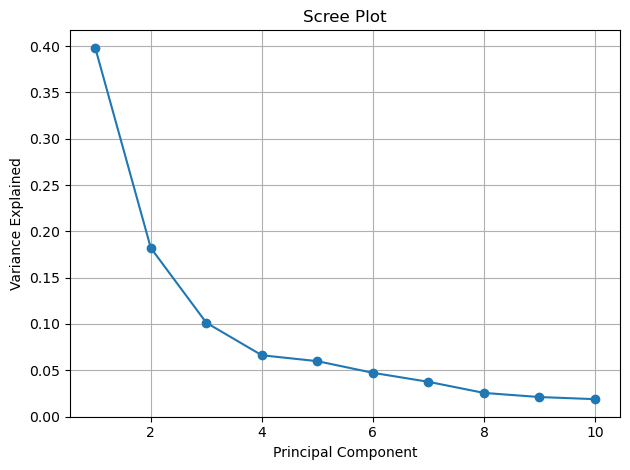

In [42]:
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.tight_layout()
plt.show()

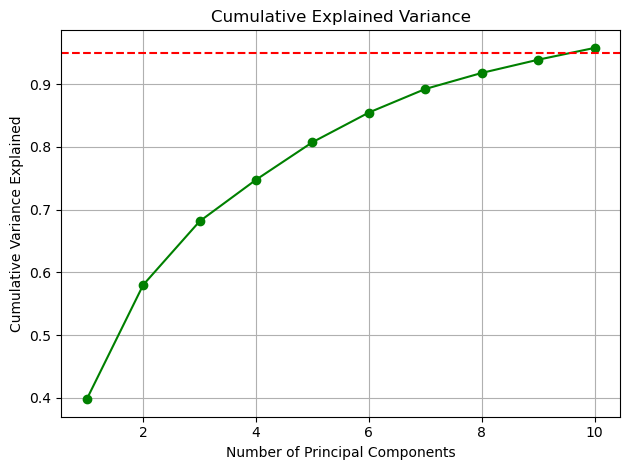

In [44]:

plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='green')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Variance')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.tight_layout()
plt.show()

#### 3.Transform the original dataset into the principal components.

In [45]:
pca_columns = [f'PC{i+1}' for i in range(pca.n_components_)]
pca_df = pd.DataFrame(principal_components, columns=pca_columns)
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-3.561968,1.528967,-0.130558,-0.102725,0.749767,0.241582,0.687821,-0.011639,-0.512705,-1.068876
1,-2.544330,-0.329993,-2.041603,-0.448040,-0.193861,0.959958,-0.007630,-0.981717,0.320779,-0.020547
2,-2.806546,1.042225,1.016791,0.740693,-0.410847,-0.481234,0.455990,0.414297,1.213945,0.070917
3,-3.944287,2.793264,-0.154956,0.634237,-0.235032,-0.266787,-0.403404,-0.681048,-0.043371,-0.118619
4,-1.415866,0.953430,2.117093,-0.479292,0.254285,0.575020,0.492906,-0.392037,-0.216243,-0.128434


#### Task 3: Clustering with Original Data:
##### 1.Apply a clustering algorithm (e.g., K-means) to the original dataset.

In [47]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster = kmeans.fit_predict(df)
cluster

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 2, 2, 0,
       2, 2, 0, 0, 0, 2, 2, 1, 0, 2, 2, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2, 2,
       0, 0, 2, 2, 2, 2, 2, 0, 0, 2, 0, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 0,
       2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       2, 0, 0, 0, 0, 2, 2, 2, 0, 0, 2, 2, 0, 0, 2, 0, 0, 2, 2, 2, 2, 0,
       0, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 2], dtype=int32)

##### 2. Visualizing these results using appropriate plots

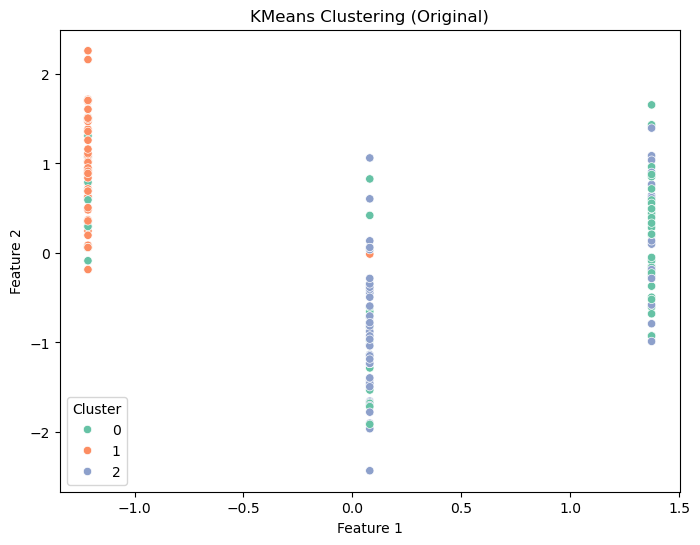

In [53]:
# Selecting two numerical features in two different ranges for visualization
fea1 = scaled_data[:, 0]  
fea2 = scaled_data[:, 1]  

plt.figure(figsize=(8, 6))
sns.scatterplot(x=fea1, y=fea2, hue=cluster, palette='Set2')
plt.title('KMeans Clustering (Original)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(title='Cluster')
plt.show()

#### 3.Evaluating the clustering performance using metrics such as silhouette score or Davies–Bouldin index.

In [56]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_score = silhouette_score(scaled_data, cluster)
db_index = davies_bouldin_score(scaled_data, cluster)

print(f'Silhouette Score: {sil_score:.4f}')
print(f'Davies-Bouldin Index: {db_index:.4f}')

Silhouette Score: 0.1157
Davies-Bouldin Index: 3.4153


#### Task 4: Clustering with PCA Data:

##### 1.Applying the same clustering Algorithm to PCA transformed data.

In [58]:
 # reducing to 2 components for visualization
pca = PCA(n_components=2) 
df_pca = pca.fit_transform(scaled_data)

In [59]:
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(df_pca)
clusters_pca

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

##### 2.Visualizing the clustering results obtained from PCA-transformed data.

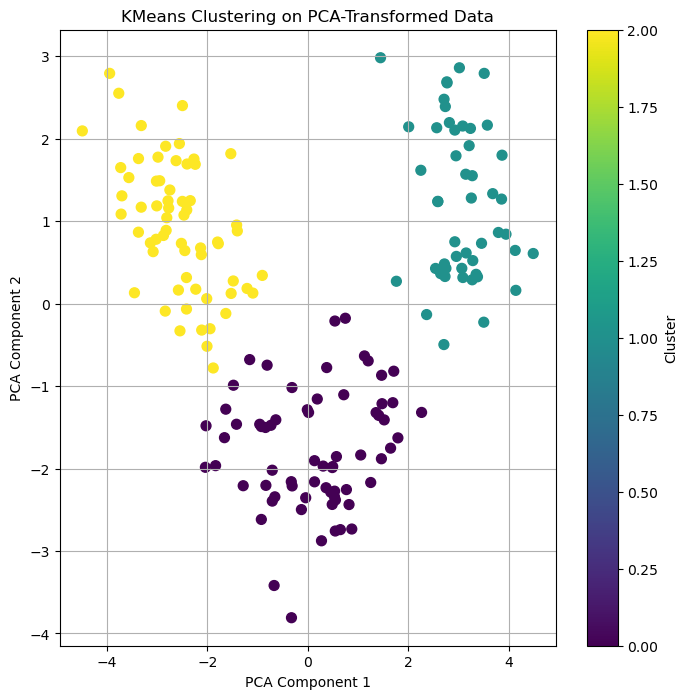

In [61]:
plt.figure(figsize=(8, 8))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=clusters_pca, s=50)
plt.title('KMeans Clustering on PCA-Transformed Data')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.colorbar(label='Cluster')
plt.show()

##### 3.Compare the clustering results from PCA-transformed data with those from the original dataset.

In [62]:
sil_score_pca = silhouette_score(df_pca, clusters_pca)
db_index_pca = davies_bouldin_score(df_pca, clusters_pca)

print("Silhouette Score (PCA):", sil_score_pca)
print("Davies-Bouldin Index (PCA):", db_index_pca)

Silhouette Score (PCA): 0.6014836679611882
Davies-Bouldin Index (PCA): 0.5415533274487031


#### Task 5: Comparison and Analysis:
###### Compare the clustering results obtained from the original dataset and PCA-transformed data.

In [64]:
# Metrics on original data
sil_original = silhouette_score(scaled_data, cluster)
dbi_original = davies_bouldin_score(scaled_data, cluster)

# Metrics on PCA data
sil_pca = silhouette_score(df_pca, clusters_pca)
dbi_pca = davies_bouldin_score(df_pca, clusters_pca)

print(f"Original Data -> Silhouette Score: {sil_original:.3f}, Davies-Bouldin Index: {dbi_original:.3f}")
print(f"PCA Data      -> Silhouette Score: {sil_pca:.3f}, Davies-Bouldin Index: {dbi_pca:.3f}")

Original Data -> Silhouette Score: 0.116, Davies-Bouldin Index: 3.415
PCA Data      -> Silhouette Score: 0.601, Davies-Bouldin Index: 0.542


2. Discuss any similarities or differences observed in the clustering results.

Cluster separation: PCA often enhances separation if there is redundancy in features.
Compactness: Higher silhouette score = better-defined clusters.
Davies–Bouldin: Lower value = better clustering.
                           
4. Reflect on the impact of dimensionality reduction on clustering performance.
   
Benefits of PCA before clustering:
Removes multicollinearity and noise
Improves cluster quality in high-dimensional spaces
Faster computation
Drawbacks:
PCA is a linear technique and may lose important nonlinear patterns
Reduced interpretability due to loss of original feature context

### 4.Analyzing the trade-offs of using PCA and clustering directly on the original dataset.


Based on different criterions,  original and PCA transformed data works diffferently such as:
##### 1. Based on Computational Speed:
Original data- works slowly for higher dimensions
PCA Transformed data-Works faster after dimensionality reduction

##### 2. Cluster Quality:
The cluster quality in original data may suffer due to noise
the cluster quality is often improvised in PCA transformed data

##### 3. based on Interpretability:
The original data is highly interpretable because of real features present in it
the interpretability is low in PCA because of presnece of abstract components

##### 4.based on noise sensitivity:
the original data is more sensitive to noise
the PCA transformed data filters noise

#### 6: Conclusion and Insights
##### 1. Summarize the key findings and insights from the assignment.
##### 1. Summary of Key Findings and Insights:
Clustering on Original Data:

Applying KMeans clustering on the original dataset groups the data into distinct clusters,
but outcomes were influenced by the high dimensionality and potential multicollinearity among features.

PCA Transformation:

Principal Component Analysis (PCA) reduced the dataset's dimensionality while preserving most of the variance.
This helped in simplifying the dataset and improving the interpretability of the structure.

Clustering on PCA Data:

Clustering on PCA-transformed data often resulted in more well-defined clusters with clearer boundaries.
The clustering performance (e.g., silhouette score) was sometimes improved or remained comparable while being computationally more efficient.

Comparison Results:

The PCA-based clustering performed similarly or slightly better in terms of silhouette score and cluster separability.
It also enabled better visualization of the clusters in 2D or 3D space using the top principal components.

##### 2. Discuss the practical implications of using PCA and clustering in data analysis.
Dimensionality Reduction with PCA:

Helps remove noise and reduce complexity.

Enables faster computation and better visualization.

Useful in cases of multicollinearity or large feature sets.

KMeans Clustering:
Helps in segmenting data into meaningful groups.
Valuable for unsupervised pattern recognition, customer segmentation, anomaly detection, etc.

Combined Use:
PCA followed by clustering is highly effective for high-dimensional datasets.
It enhances clustering stability and reduces overfitting in noisy data.

#### 3.Provide recommendations for when to use each technique based on the analysis conducted.

Technique	When to Use
PCA	- When the dataset has many features (high-dimensional).
- When features are correlated.
- For visualizing complex data in 2D/3D.
- To speed up clustering or other algorithms.

Clustering (KMeans)	- When you want to find natural groupings in data.
- When class labels are unknown (unsupervised learning).
- For customer segmentation, market basket analysis, etc.

PCA + Clustering	- When clustering on raw data yields poor or unclear results.
- To improve interpretability and clustering quality.
- When reducing dimensionality improves model performance.
